In [1]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from stat_online.lin_bandits.convex_functions_jax import get_functions
def generate_data(T, d, nonlinearity, random_state=None):
    rng = np.random.default_rng(random_state)
    # Generate X uniformly from a d-dimensional ball of radius 1
    X = rng.normal(size=(T, d)) 
    X /= np.linalg.norm(X,ord=2, axis=1, keepdims=True) 
    # radii = rng.uniform(0, 1, size=(T, 1))
    X = X * 2  #* radii

    # Linear transformation
    W = rng.standard_cauchy(size=(d,))
    W /= np.linalg.norm(W, )  # Normalize W to unit norm
    W = W * rng.uniform(0.7, 0.95)  # Scale W to have a random magnitude
    linear = X @ W

    # linear = linear[np.abs(linear) < 0.7]

    # Apply nonlinearity
    y = nonlinearity(linear) + rng.normal(loc = 0, scale = 0.02, size= linear.shape)
    return X, y, linear

def generate_data2(T, d, nonlinearities, random_state=None):
    rng = np.random.default_rng(random_state)
    # Generate X uniformly from a d-dimensional ball of radius 1
    X = rng.normal(size=(T, d)) 
    X /= np.linalg.norm(X,ord=2, axis=1, keepdims=True) 
    # radii = rng.uniform(0, 1, size=(T, 1))
    X = X * 2  #* radii

    # Linear transformation
    W = rng.standard_cauchy(size=(d,))
    W /= np.linalg.norm(W, )  # Normalize W to unit norm
    W = W * rng.uniform(0.7, 0.95)  # Scale W to have a random magnitude
    linear = X @ W

    # linear = linear[np.abs(linear) < 0.7]

    # Apply nonlinearity
    y = np.zeros_like(linear, dtype=float)
    geq_0_ind = (linear > 0)
    y[geq_0_ind] = nonlinearities[0](linear[geq_0_ind]) + rng.normal(loc = 0, scale = 0.02, size= sum(geq_0_ind))
    geq_0_ind = (linear <= 0)
    y[geq_0_ind] = nonlinearities[1](linear[geq_0_ind]) + rng.normal(loc = 0, scale = 0.02, size= sum(geq_0_ind))

    return X, y, linear

nonlinearities = get_functions(x_scale=2)


T=10000
d=50
X, y, linears = generate_data(T=T, d=d, nonlinearity=nonlinearities[9], random_state=42)
# X, y, linears = generate_data(T=T, d=d, nonlinearities=[nonlinearities[4], nonlinearities[7]], random_state=42)

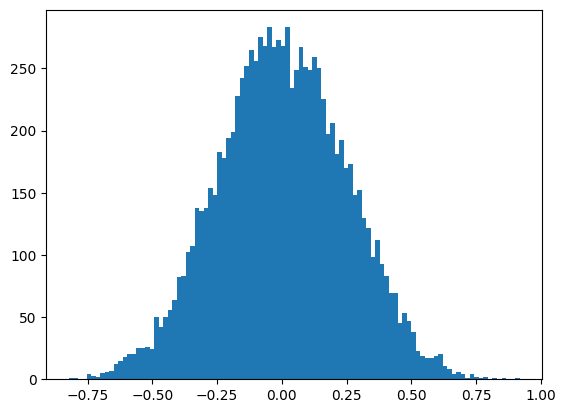

In [2]:
_ = plt.hist(linears, bins=100)

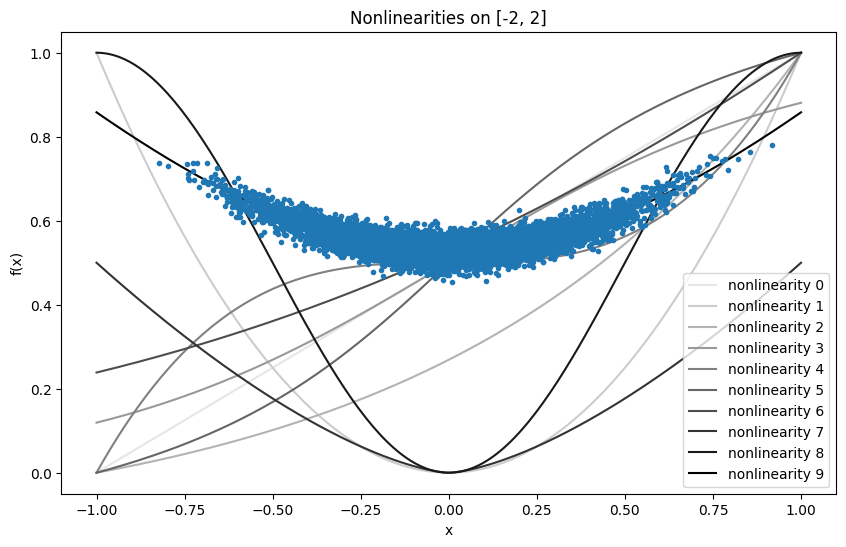

In [3]:


x = np.linspace(-1, 1, 200)
plt.figure(figsize=(10, 6))

for i, f in enumerate(nonlinearities):
    y_plot = f(x)
    color = str(1 - (i + 1) / (len(nonlinearities)))  # Чем больше номер, тем темнее цвет
    plt.plot(x, y_plot, color=color, label=f'nonlinearity {i}')

plt.plot(linears, y, ".")

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Nonlinearities on [-2, 2]')
plt.legend()
plt.show()

In [26]:
a = [[4], [5],[6,7]]
from itertools import chain
list(chain.from_iterable(a))

[4, 5, 6, 7]

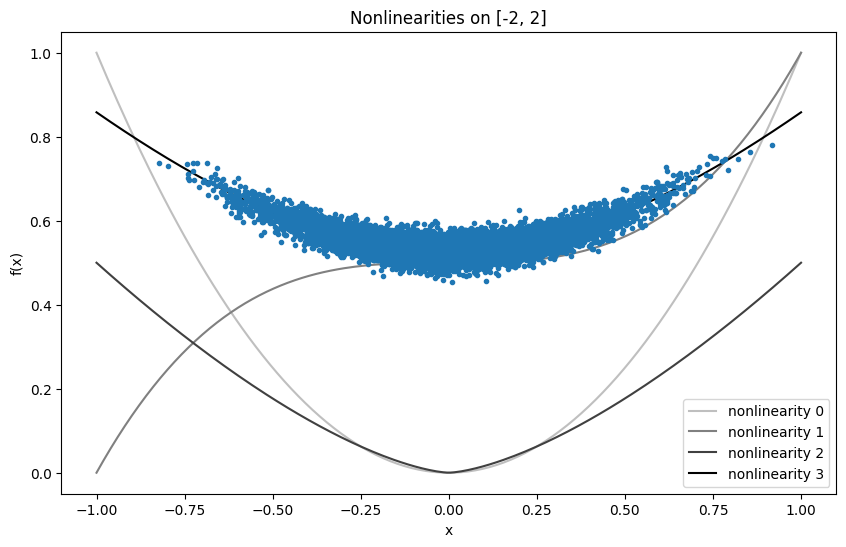

In [32]:
x = np.linspace(-1, 1, 200)
plt.figure(figsize=(10, 6))
indices = [1, 4, 7, 9]
sublist = [nonlinearities[i] for i in indices]
for i, f in enumerate(sublist):
    y_plot = f(x)
    color = str(1 - (i + 1) / (len(sublist)))  # Чем больше номер, тем темнее цвет
    plt.plot(x, y_plot, color=color, label=f'nonlinearity {i}')

plt.plot(linears, y, ".")

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Nonlinearities on [-2, 2]')
plt.legend()
plt.show()

In [5]:
from stat_online.lin_bandits.contextual_mab import OnlineGradArmOptimizer, GeneralizedLinearFunction
from stat_online.ucb_algorithm import (
        Strategy, 
        UCBAlgorithm,
        EpsilonGreedyAlgorithm, 
        Exp3Algorithm, 
        GroupedUCB, 
        CORRAL,
        DynamicBalancing,
        DDRB,
        LimitedAdvice
    )
from stat_online.ucb_algorithm import Arm, ContextualArm, dummyContextualArm

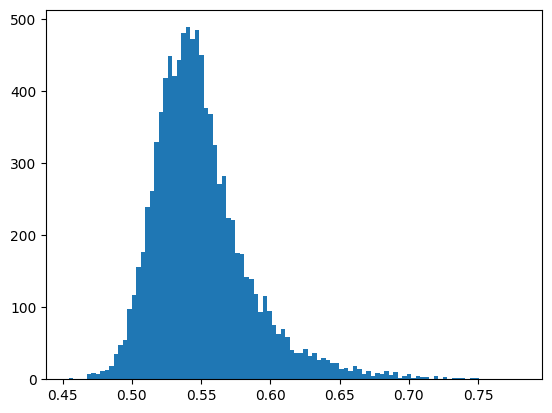

In [6]:
_ = plt.hist(y, bins=100)

In [19]:
from dataclasses import dataclass
from time import time
from joblib import Parallel, delayed, parallel_backend
from stat_online.ucb_algorithm import SuccessiveEliminationAlgorithm
from stat_online.utils.visualization import AlgRes, plot_experiment_results
from itertools import product
import jax

from stat_online.lin_bandits.loss_functions import square_loss, abs_loss


BEST_ARM_NUMBER =9
strategies =  [UCBAlgorithm, LimitedAdvice, DDRB, CORRAL, ] #[GroupedUCB, UCBAlgorithm, EpsilonGreedyAlgorithm] #, Exp3Algorithm ] #, SuccessiveEliminationAlgorithm]
def run_once():
    T = 1500 # maximal number of steps
    d=5
    X, y, linears = generate_data(T=T, d=d, nonlinearity=nonlinearities[BEST_ARM_NUMBER ], random_state=42)
    # X, y, linears = generate_data2(T=T, d=d, nonlinearities=[nonlinearities[4],nonlinearities[7] ], random_state=42)

    K = 10 # num arms
    num_optimize = 3 # number of arms to optimize


    def get_arms_instance(K, lr_scaler = 1., D = 0.1, G = 0.1, nonlinearities=nonlinearities, is_context=False):
        functions = [GeneralizedLinearFunction(n_params=d, nonlinearity=nonlinearities[i])\
                    for i in range(K)]
        optimizers = [OnlineGradArmOptimizer(func,lr_scaler, square_loss, D, G, reg_term=1e-4) for func in functions]
        if is_context == "no":
            arms = [Arm(optimizer, delta=0.01) for func, optimizer in zip(functions, optimizers)]
        elif is_context == "context":
            arms = [ContextualArm(optimizer, d, delta=0.01, alpha=15) for func, optimizer in zip(functions, optimizers)]
        elif is_context == "dummy_context":
            arms = [dummyContextualArm(optimizer, d, delta=0.01, alpha=1) for func, optimizer in zip(functions, optimizers)]
        return arms

    def run_instance(algo, x, y, T):
        start_time = time()
        algo.run(X[:T], y[:T])
        delta_time = time() - start_time

        return algo, delta_time

    def run_experiment(X, y, T, K, num_optimize, strategy, nonlinearities, is_context):
        arms = get_arms_instance(K, nonlinearities = nonlinearities, is_context=is_context)

        algo: Strategy = strategy(arms=arms, 
                                num_optimize=num_optimize, 
                                T=T,
                                delta = 0.01
                                )
        start_time = time()
        algo.run(X[:T], y[:T])
        delta_time = time() - start_time

        return algo, delta_time

    run_experiment_del = delayed(run_experiment)



    n_optims = range(1, num_optimize + 1)

    strategy_n_opt_pairs = [(strategy, n_optim) for strategy in strategies for n_optim in n_optims]
    context_types = ["no"] #, "context", "dummy_context"]
    strategy_n_opt_pairs = list(product(strategies, n_optims, context_types))
    alg_results_list = Parallel(n_jobs=12, )(
        run_experiment_del(X, y, T, K, n_optim, strategy, nonlinearities, is_context)
        for strategy, n_optim, is_context in strategy_n_opt_pairs
    )

    alg_results = dict()
    for (alg_res, delta_time), (strategy, n_optim, is_context) in zip(alg_results_list, strategy_n_opt_pairs):
        alg_name = f"{strategy.__name__}_{n_optim}_{is_context}"

        res = AlgRes(
            algname=alg_name,
            strategy_class=strategy,
            num_optimized_arms=n_optim,
            arm_selection_hist=alg_res.selection_history,
            alg_loss_hist=alg_res.loss_history,
            max_steps=T,
            n_arms=K,
            runtime=delta_time,
            learned_algorithm=alg_res
            )
        alg_results[alg_name] = res
    return alg_results

res_list = [run_once() for _ in range(5)]

In [20]:
res_example = res_list[0]
res_dict = {k: [r[k] for r in res_list] for k in res_example.keys()}

In [21]:
f"exp_results/experiment_results_{BEST_ARM_NUMBER}.pdf"

'exp_results/experiment_results_9.pdf'

AssertionError: 

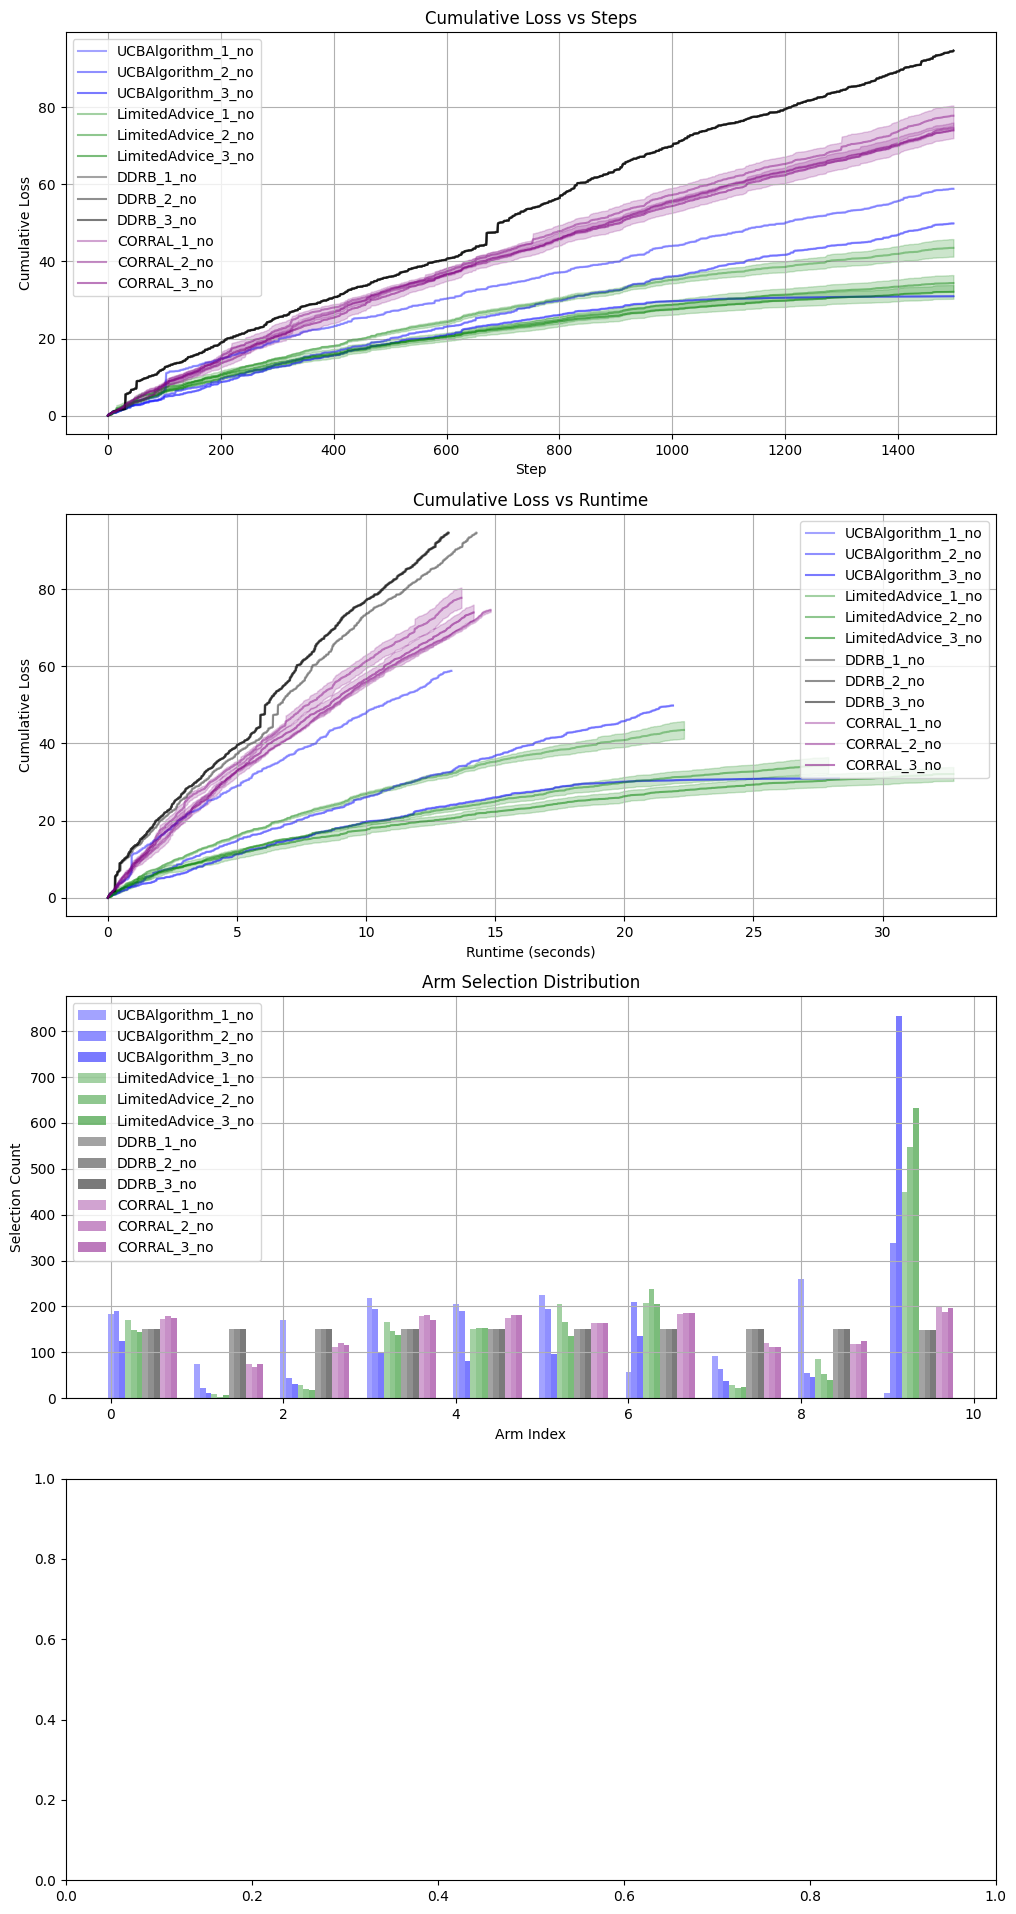

In [22]:
from stat_online.utils.visualization import plot_experiment_results, save_plots

fig = plot_experiment_results(res_dict, strategies)

In [ ]:
a = [1,2,4,5]
a = list(filter(lambda x: x > 3, a))
a

[4, 5]

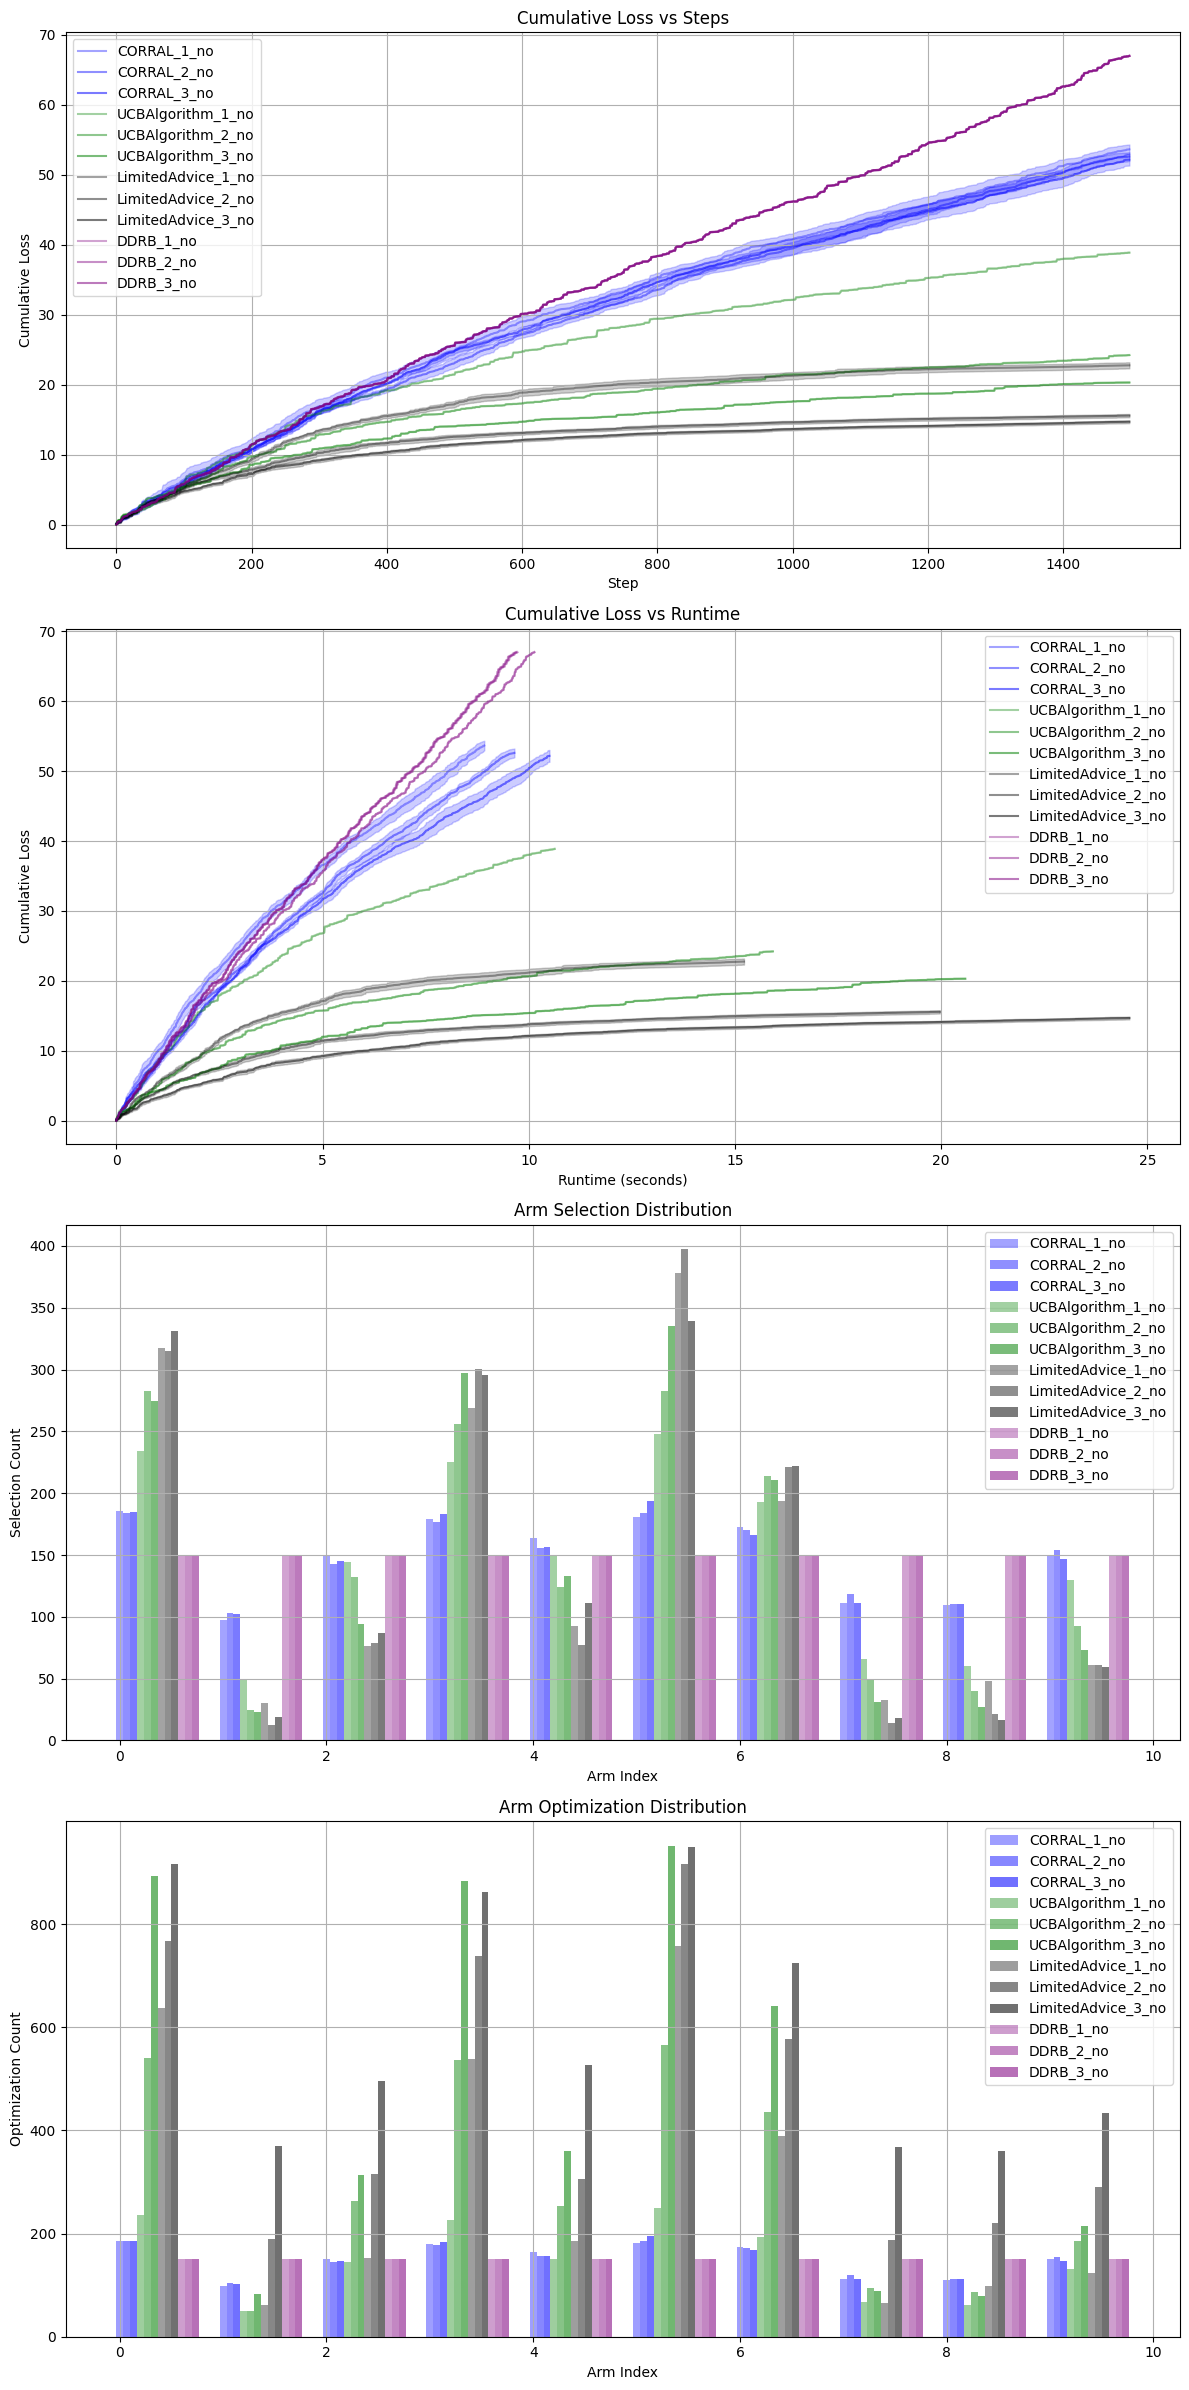

In [ ]:
from stat_online.utils.visualization import plot_experiment_results, save_plots

fig = plot_experiment_results(res_dict, strategies)

save_plots(fig, f"./exp_results/experiment_results_context_{BEST_ARM_NUMBER}.pdf")
fig

In [ ]:
res_dict["GroupedUCB_3_no"][3].learned_algorithm.group_usages

KeyError: 'GroupedUCB_3_no'

# отчет об эксперименте
постановка эксперимента. Эксперимент рассматривался в realizability assumption. Рассмотрели 10 функций. В качестве функций использовались обобщенно линейные функции.  То есть $g_i(x, w) = \sigma_i(w^Tx)$. Причем $w \in B_1(0) \subset \mathbb{R}^d$; $x \in B_2(0) \subset \mathbb{R}^d$ генерировались из нормального распределения и нормировались. Поэтому $w^Tx \in [-2, 2]$. Для генерации $y_i$ используется одна из функций $g^*(x, w^*)$. из нее $y_i = g^*(x_i, w^*) + \xi$. 

Нелинейности и семплы показаны на рисунке \ref{}. На рисунке \ref{} показан кумулятивный лосс в зависимости от времени работы. Видим, что при тренировке нескольких моделей лосс уменьшается, но возрастает время тренировки в одном потоке. Кроме UCB мы реализовали несколько дополнительных стратегий для сравнения. Exp3 взяли из \cite{prediction_learning_and_games} Theorem 6.10. параметры взяли как в теореме, но уменьшили бонус за поиск, потому как алгоритм переходил в over exploration. 